# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFSCar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>

<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final - Classificação Automática de Documentos Jurídicos</center>

**Nome**: Anderson Cristiano Sassaki Gonçalves

**RA**: 821675

**Nome**: Lorenzo Grippo Chiachio

**RA**: 823917


---
## Visão geral da solução

O objetivo deste notebook é construir uma solução completa para a competição de classificação de documentos jurídicos da base VICTOR/STF. Cada amostra possui um identificador (`Id`), um texto extraído de documento jurídico (`Body`) e, no conjunto de treino, uma categoria (`Category`). As classes válidas são:

- `0`: Acórdão;
- `1`: Agravo de Recurso Extraordinário (ARE);
- `2`: Despacho;
- `3`: Recurso Extraordinário (RE);
- `4`: Sentença.

A métrica de referência da competição é o F1-Score, portanto os experimentos priorizam `f1_macro`, que penaliza modelos que acertam apenas a classe majoritária. A organização segue o padrão usado no projeto anterior de Aprendizado de Máquina: o notebook documenta as decisões e chama funções implementadas em `scripts/`, enquanto cada etapa do pipeline fica isolada o suficiente para ser refeita sem quebrar as demais.

O fluxo completo executado aqui é:

1. Carregamento e validação dos CSVs da competição;
2. Análise exploratória dos textos e das classes;
3. Pré-processamento textual robusto para ruídos de OCR e linguagem jurídica;
4. Extração de sinais linguísticos e jurídicos auxiliares;
5. Modelos clássicos com TF-IDF;
6. Validação cruzada dos melhores modelos clássicos;
7. Embeddings densos com SentenceTransformers;
8. Fine-tuning de Transformer no melhor dispositivo disponível (`cuda`, `mps` ou `cpu`);
9. Geração de arquivos de submissão.


---
## Dependências e estratégia de dispositivo

A célula abaixo instala apenas o que estiver ausente. A instalação é feita dentro do ambiente Python usado pelo notebook, o que evita depender de comandos externos ou de configuração manual. O conjunto `requirements.txt` cobre análise, visualização e modelos clássicos. O conjunto `requirements-advanced.txt` cobre embeddings e Transformers. A dependência `bitsandbytes`, necessária apenas para QLoRA em GPUs NVIDIA/Linux, ficou separada em `requirements-nvidia.txt` para não quebrar máquinas Mac/MPS.

Depois das dependências, o notebook detecta automaticamente o dispositivo disponível:

- se houver GPU NVIDIA, usa `cuda`;
- se estiver em Apple Silicon com suporte PyTorch, usa `mps`;
- se nenhum acelerador estiver disponível, usa `cpu`.

Não há flags manuais para ativar ou desativar partes do pipeline. O mesmo fluxo é executado sempre; o que muda é o dispositivo, o tamanho de batch e a precisão usada pelo treino Transformer.


In [1]:
import importlib.util
import subprocess
import sys

BASE_MODULES = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "joblib"]
ADVANCED_MODULES = ["torch", "transformers", "datasets", "sentence_transformers", "accelerate"]

missing_base = [pkg for pkg in BASE_MODULES if importlib.util.find_spec(pkg) is None]
if missing_base:
    print("Instalando dependências base ausentes:", missing_base)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Dependências base já disponíveis.")

missing_advanced = [pkg for pkg in ADVANCED_MODULES if importlib.util.find_spec(pkg) is None]
if missing_advanced:
    print("Instalando dependências avançadas ausentes:", missing_advanced)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-advanced.txt"])
else:
    print("Dependências avançadas já disponíveis.")

importlib.invalidate_caches()
print("Ambiente pronto para executar o pipeline completo.")


Dependências base já disponíveis.
Dependências avançadas já disponíveis.
Ambiente pronto para executar o pipeline completo.


In [23]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Importação dos módulos do projeto

Nesta etapa, importamos apenas as funções públicas dos scripts. Essa separação é importante porque permite que o notebook fique enxuto e explicativo, enquanto a lógica que pode ser testada, reaproveitada ou substituída fica nos arquivos `.py` correspondentes.

Os quatro scripts principais são:

- `analise_exploratoria.py`: leitura dos dados, validações, estatísticas e gráficos;
- `preprocessamento.py`: limpeza textual, normalização jurídica, chunking e features linguísticas;
- `experimentos.py`: modelos clássicos, embeddings, Transformers e submissões;
- `analise_resultados.py`: rankings, matrizes de confusão, relatórios e tabelas finais.


In [2]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str((PROJECT_DIR / "scripts").resolve()))

from analise_exploratoria import (
    add_text_statistics,
    get_top_terms,
    load_competition_data,
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_terms,
    summarize_dataset,
    validate_schema,
    split_labeled_unlabeled,
)
from preprocessamento import (
    CLASS_NAMES,
    TextPreprocessConfig,
    add_clean_text_column,
    extract_basic_nlp_features,
    extract_legal_signal_features,
)
from experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_chunked_sentence_embedding_matrix,
    build_embedding_classifier_zoo,
    build_sentence_embedding_matrix,
    build_sparse_model_zoo,

    build_training_set_with_pseudo_labels,
    cross_validate_best_models,

    detect_label_issues_with_cv,
    evaluate_embedding_classifier,
    evaluate_model_zoo,
    fine_tune_transformer_classifier,
    fit_embedding_classifier_on_full_train,
    fit_model_on_full_train,
    generate_embedding_submission,
    generate_submission,
    generate_transformer_submission,

    pseudo_label_unlabeled_samples,
    save_model,
    select_best_model,
    transformer_candidate_models,
)
from analise_resultados import (
    classification_report_frame,
    plot_confusion_matrix,
    plot_metric_comparison,
    rank_results,
    save_results_table,
)

pd.set_option("display.max_colwidth", 160)

runtime_profile = auto_runtime_profile(prefer_transformer=True)
print("Diretório do projeto:", PROJECT_DIR)
print("Perfil automático:", runtime_profile["notes"])
display(pd.DataFrame([
    {
        "device": runtime_profile["device"],
        "advanced_available": runtime_profile["advanced_available"],
        "classical_model_zoo": runtime_profile["classical_model_zoo"],
        "run_classical_baselines": runtime_profile["run_classical_baselines"],
        "run_embeddings": runtime_profile["run_embeddings"],
        "run_transformer": runtime_profile["run_transformer"],
        "batch_transformer": runtime_profile["transformer_batch_size"],
        "max_length_transformer": runtime_profile["transformer_max_length"],
    }
]))


Diretório do projeto: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao
Perfil automático: Complete pipeline enabled automatically on cpu.


,device,advanced_available,classical_model_zoo,run_classical_baselines,run_embeddings,run_transformer,batch_transformer,max_length_transformer
0,cpu,True,full,True,True,True,1,512


---

## 1. Carregamento e validação dos dados

Os arquivos esperados são `train.csv`, `test.csv` e `sample_submission.csv`. O carregador procura primeiro em `data/`, mas também aceita os arquivos na raiz do projeto, o que facilita alternar entre execução local, Kaggle e servidor remoto.

Um detalhe importante observado nesta base é a presença de amostras com `Category = -1`. Essas linhas não são rótulos válidos da competição, então são separadas do conjunto supervisionado em `train_unlabeled`. Elas não são descartadas: mais à frente, o notebook usa um modelo probabilístico de alta confiança para propor pseudo-rótulos e reaproveitar parte dessas amostras no treino final.

Também tratamos a possibilidade de rótulos incorretos. Depois dos baselines clássicos, uma etapa de auditoria com previsões fora da dobra (`out-of-fold`) sinaliza exemplos em que o rótulo original discorda de uma previsão muito confiante. Esses casos são salvos para inspeção e apenas correções extremamente confiantes entram automaticamente no conjunto final.


In [3]:
train_df, test_df, sample_df = load_competition_data(DATA_DIR)
schema_report = validate_schema(train_df, test_df, sample_df)
train_labeled, train_unlabeled = split_labeled_unlabeled(train_df)

print(f"Total no train.csv: {len(train_df)}")
print(f"Amostras rotuladas válidas: {len(train_labeled)}")
print(f"Amostras sem rótulo válido (Category=-1 ou fora de 0..4): {len(train_unlabeled)}")
print(f"Amostras de teste: {len(test_df)}")

print("Classes usadas no treinamento:")
for label, name in CLASS_NAMES.items():
    print(f"{label}: {name}")

schema_report


Total no train.csv: 22680
Amostras rotuladas válidas: 20412
Amostras sem rótulo válido (Category=-1 ou fora de 0..4): 2268
Amostras de teste: 2521
Classes usadas no treinamento:
0: Acordao
1: Agravo de Recurso Extraordinario (ARE)
2: Despacho
3: Recurso Extraordinario (RE)
4: Sentenca


{'train_shape': (22680, 3),
 'test_shape': (2521, 2),
 'sample_shape': (15, 2),
 'train_missing_columns': [],
 'test_missing_columns': [],
 'sample_missing_columns': [],
 'train_nulls': {'Id': 0, 'Body': 0, 'Category': 0},
 'test_nulls': {'Id': 0, 'Body': 0},
 'duplicated_train_ids': 0,
 'duplicated_test_ids': 0,
 'invalid_category_count': 2268,
 'invalid_category_examples': [{'Id': 9716, 'Category': -1},
  {'Id': 25112, 'Category': -1},
  {'Id': 11274, 'Category': -1},
  {'Id': 20985, 'Category': -1},
  {'Id': 23109, 'Category': -1},
  {'Id': 21386, 'Category': -1},
  {'Id': 21334, 'Category': -1},
  {'Id': 20980, 'Category': -1},
  {'Id': 18398, 'Category': -1},
  {'Id': 7787, 'Category': -1}]}

In [4]:
display(train_labeled.head())
display(test_df.head())
if sample_df is not None:
    display(sample_df.head())

,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o paraÃ­ba geral isonomia contido ARTIGO_5Âº caput cf e preceito que garante isonomia entre servidores ativos ina...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande paga pelo inss modo garantir empregado manu...",3


,Id,Body
0,9213,"{""um regime democrática direito qual seja da separação dos poderes recurso inominado parte autora improvido sem condenação ônus sucumbenciais por força conc..."
1,17427,"{""controvérsia fato que requerente participante rpps junto prefeitura municipal roca sales desde que valores atinentes aposentadorias rurais não são essenci..."
2,4753,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente turma recursal dos juizados especiais paraíba união por sua..."
3,4640,"{""advocacia geral união procuradoria união estado paraíba divisão atuação nos juizados especiais federais ARTIGO_169 despesa com pessoal ativo inativo união..."
4,20412,"{""ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande pede deferimento campina grande de dezembro ..."


,Id,Category
0,7271,3
1,861,4
2,5391,0
3,5192,3
4,5735,1


---
## 2. Análise exploratória

A análise exploratória tem três objetivos principais:

1. Entender o desbalanceamento entre as cinco classes;
2. Medir o tamanho e a variabilidade dos documentos;
3. Identificar termos e expressões que ajudam a caracterizar cada tipo de peça jurídica.

Esse diagnóstico orienta as escolhas seguintes. Por exemplo, se uma classe é muito menor que as demais, modelos com `class_weight='balanced'` e avaliação por `f1_macro` se tornam mais adequados que acurácia pura. Se os textos são muito longos, também precisamos pensar em chunking ou modelos de contexto longo.


In [5]:
eda = summarize_dataset(train_labeled)
train_stats = eda["data_with_stats"]

print("Distribuição de classes")
display(eda["class_distribution"])

print("Valores ausentes")
display(eda["missing_summary"])

print("Resumo de tamanho por classe")
display(eda["length_summary"])


Distribuição de classes


,Category,count,percent
3,0,665,3.257888
1,1,3529,17.288850
4,2,439,2.150696
0,3,12876,63.080541
2,4,2903,14.222026


Valores ausentes


,missing
Id,0
Body,0
Category,0


Resumo de tamanho por classe


n_chars                                                           \
            count         mean         std    min      25%     50%     75%   
Category                                                                     
0           665.0  2011.908271  907.395586  155.0  1292.00  2119.0  2615.0   
1          3529.0  1578.096345  735.338974    4.0  1086.00  1456.0  2016.0   
2           439.0  1195.735763  852.372715  113.0   443.00  1154.0  1508.5   
3         12876.0  1746.595216  704.201052   33.0  1360.75  1712.0  2124.0   
4          2903.0  2046.951085  771.020978   94.0  1602.00  1931.0  2640.0   

                  n_words              ...               unique_word_ratio  \
             max    count        mean  ...    75%    max             count   
Category                               ...                                   
0         4798.0    665.0  251.539850  ...  326.0  576.0             665.0   
1         5702.0   3529.0  195.200057  ...  248.0  685.0            3529.0   
2         6867.0    439.0  149.036446  ...  186.5  844.0             439.0   
3         5923.0  12876.0  213.882883  ...  260.0  781.0           12876.0   
4         6448.0   2903.0  254.391319  ...  324.0  837.0            2903.0   

                                                                           
              mean       std       min       25%       50%       75%  max  
Category                                                                   
0         0.773313  0.095599  0.493671  0.719008  0.772727  0.827206  1.0  
1         0.765190  0.088360  0.287037  0.708812  0.768293  0.821138  1.0  
2         0.771077  0.125442  0.496445  0.655629  0.750000  0.867839  1.0  
3         0.748295  0.080344  0.311450  0.700472  0.748503  0.796667  1.0  
4         0.712588  0.096364  0.322464  0.648438  0.698551  0.768298  1.0  

[5 rows x 24 columns]

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

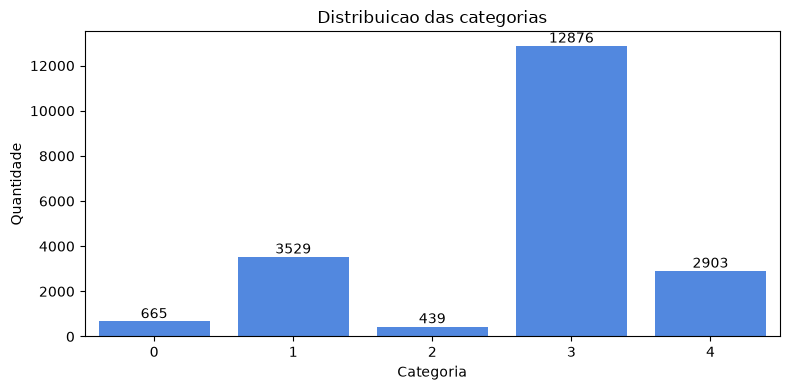

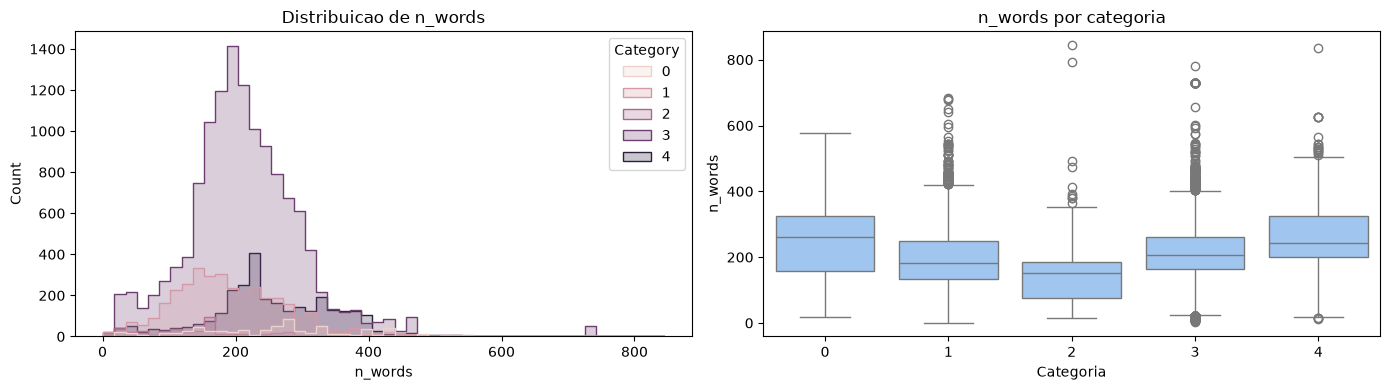

In [6]:
plot_class_distribution(eda["class_distribution"])
plot_text_length_distribution(train_stats, metric="n_words")

A distribuição de classes e de tamanho dos textos deve ser lida junto com o contexto jurídico. Classes como RE e ARE tendem a compartilhar vocabulário, o que pode causar confusão entre elas. Despachos, por outro lado, podem conter textos mais curtos e fórmulas administrativas recorrentes. A análise de termos por classe abaixo ajuda a verificar se o modelo terá pistas lexicais claras ou se dependerá de representações mais semânticas.


,Category,rank,term,mean_tfidf
0,0,1,que,0.036901
1,0,2,dos,0.031524
2,0,3,nã,0.029472
3,0,4,por,0.026014
4,0,5,para,0.024199
5,0,6,nos,0.023587
6,0,7,federal,0.023571
7,0,8,recurso,0.022599
8,0,9,com,0.022064
9,0,10,relator,0.021283


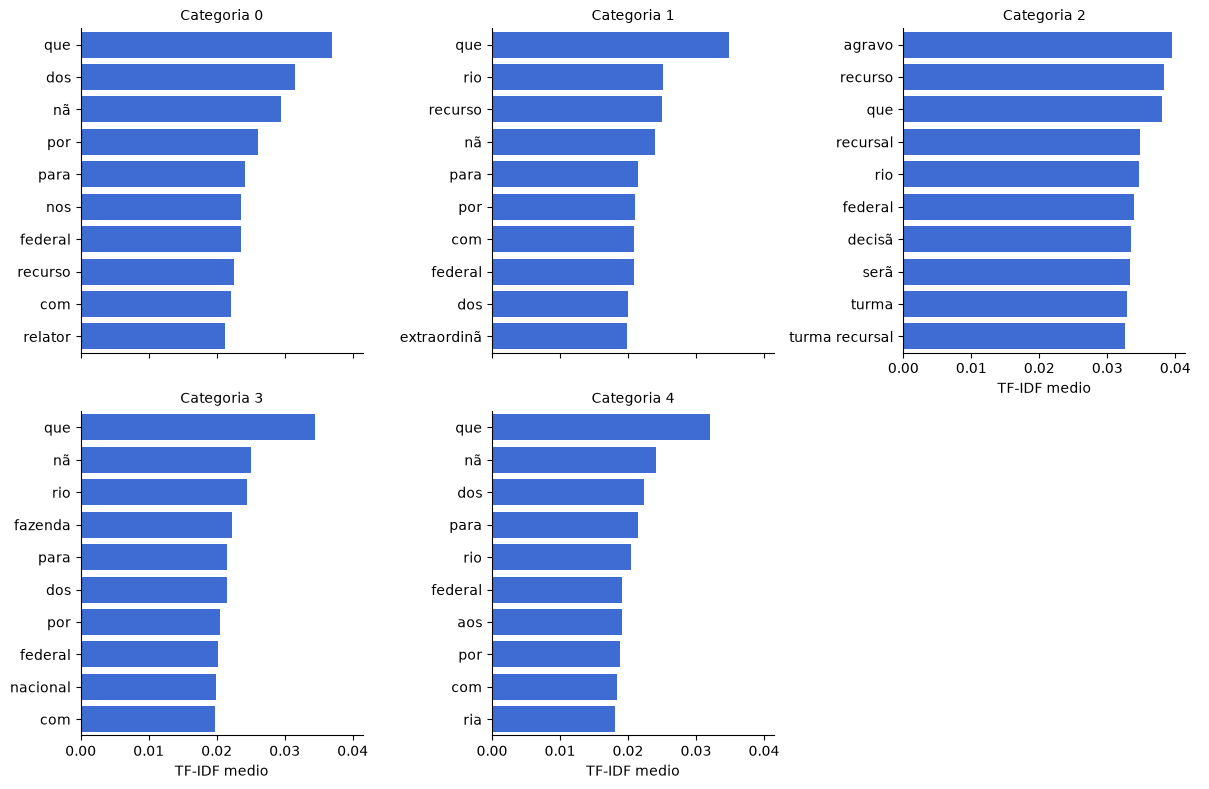

In [7]:
top_terms = get_top_terms(train_labeled, n_terms=12)
display(top_terms.head(30))
plot_top_terms(top_terms, n_terms=10)

---
## 3. Pré-processamento textual

Os textos da base vêm de documentos jurídicos reais e podem carregar problemas típicos de OCR: quebras de linha artificiais, hifenização no meio de palavras, assinaturas digitais, carimbos, números processuais e referências legais em formatos variados.

O pré-processamento adotado aqui é propositalmente modular. A função `add_clean_text_column` cria uma coluna `Body_clean`, que passa a ser a interface entre limpeza e modelagem. Se no futuro a limpeza for trocada por uma abordagem melhor, basta preservar essa coluna final para que os modelos continuem funcionando.

As decisões principais são:

- converter para minúsculas;
- remover acentos para reduzir variações superficiais;
- normalizar números de processo, datas, valores monetários e referências a artigos de lei;
- manter stopwords por padrão, pois em textos jurídicos termos funcionais e fórmulas podem carregar sinal de estilo e tipo documental;
- remover tokens muito curtos e ruídos evidentes.


In [8]:
preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)

train_clean = add_clean_text_column(train_labeled, config=preprocess_config)
test_clean = add_clean_text_column(test_df, config=preprocess_config)

train_clean[["Id", "Category", "Body", "Body_clean"]].head(3)

,Id,Category,Body,Body_clean
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",conclusa diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_ iii constituia artigo federal sera admitido conheci...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",artigo_ gecen gacen sera devidas aos titulares dos empregos cargos pa blicos que tratam artigo_ desta lei que cara ter permanente realizarem atividades comb...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",seguir desacerto decisa que negou seguimento recurso extraordina rio equa voco decisa discutida constitucionalidade prazo ma nimo anos para que impedimento ...


(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

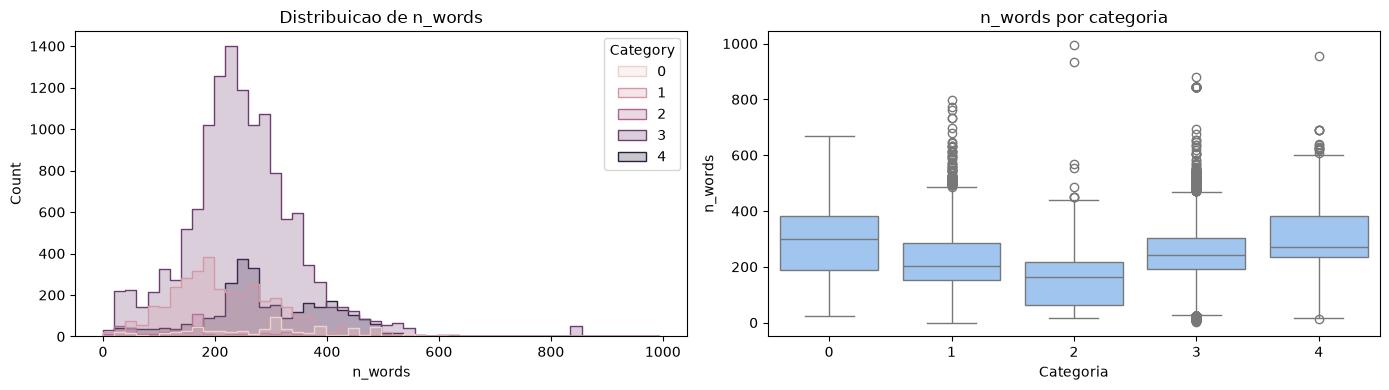

In [9]:
train_clean_stats = add_text_statistics(train_clean, text_col="Body_clean")
plot_text_length_distribution(train_clean_stats, metric="n_words")

---
## 4. Tarefas básicas de PLN e features de domínio

O enunciado do projeto pede o uso de tarefas básicas de PLN quando fizer sentido. Para este problema, usamos duas famílias de atributos auxiliares:

1. **Sinais jurídicos determinísticos**, como frequência de expressões associadas a acórdão, ARE, RE, despacho e sentença;
2. **Sinais linguísticos opcionais**, como contagens de PoS e entidades nomeadas via spaCy, quando o modelo de português estiver disponível.

Essas features não substituem TF-IDF nem Transformers. Elas funcionam como uma camada interpretável para análise: ajudam a entender que pistas jurídicas o pipeline consegue observar diretamente.


In [10]:
legal_features = extract_legal_signal_features(train_clean, text_col="Body_clean")
nlp_features = extract_basic_nlp_features(train_clean, text_col="Body")

print("Features jurídicas:", legal_features.shape)
display(legal_features.head())

print("Features básicas de PLN/fallback:", nlp_features.shape)
display(nlp_features.head())

Features jurídicas: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,61,440,0.0,0.0,0.901639,0,0,0,0.000000,0.000000,0.000000,0.016393,0.000000,0.0
1,151,1029,0.0,0.0,0.708609,0,0,0,0.000000,0.019868,0.006623,0.000000,0.000000,0.0
2,235,1742,0.0,0.0,0.740426,0,0,0,0.000000,0.000000,0.004255,0.004255,0.000000,0.0
3,365,2565,0.0,0.0,0.632877,0,0,2,0.000000,0.000000,0.000000,0.002740,0.000000,0.0
4,532,3662,0.0,0.0,0.595865,0,0,1,0.018797,0.000000,0.005639,0.001880,0.005639,0.0


Features básicas de PLN/fallback: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,61,440,0.0,0.0,0.901639,0,0,0,0.000000,0.000000,0.000000,0.016393,0.000000,0.0
1,151,1029,0.0,0.0,0.708609,0,0,0,0.000000,0.019868,0.006623,0.000000,0.000000,0.0
2,235,1742,0.0,0.0,0.740426,0,0,0,0.000000,0.000000,0.004255,0.004255,0.000000,0.0
3,365,2565,0.0,0.0,0.632877,0,0,2,0.000000,0.000000,0.000000,0.002740,0.000000,0.0
4,532,3662,0.0,0.0,0.595865,0,0,1,0.018797,0.000000,0.005639,0.001880,0.005639,0.0


---
## 5. Modelos clássicos com TF-IDF

Os modelos clássicos são a base de comparação. Eles têm duas vantagens importantes neste projeto:

- são fortes em classificação textual quando há vocabulário discriminativo;
- são mais baratos que Transformers, o que permite testar rapidamente hipóteses de limpeza, n-gramas e balanceamento.

A bateria inclui modelos complementares:

- `DummyClassifier`, para estabelecer o mínimo aceitável;
- `ComplementNB`, muito competitivo em texto esparso e desbalanceado;
- Regressão Logística com TF-IDF de palavras;
- LinearSVC com n-gramas de caracteres, robusto a ruídos de OCR;
- SGD com perda logística;
- união de TF-IDF de palavras e caracteres.

A métrica principal é `f1_macro`, pois ela dá peso semelhante para classes frequentes e raras.


/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,f1_macro,f1_weighted,accuracy,precision_macro,recall_macro
0,sgd_logloss_word_tfidf,0.898012,0.920052,0.920157,0.904347,0.893998
1,logreg_word_tfidf,0.891809,0.906811,0.904972,0.884498,0.903353
2,linear_svc_char_tfidf,0.890593,0.912465,0.911830,0.888686,0.894119
3,logreg_word_char_union,0.889332,0.905531,0.903502,0.876177,0.906559
4,complement_nb_word_tfidf,0.838568,0.861856,0.859417,0.817584,0.865587
5,dummy_most_frequent,0.154701,0.487822,0.630664,0.126133,0.200000


Resultados holdout salvos em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/model_results_holdout.csv


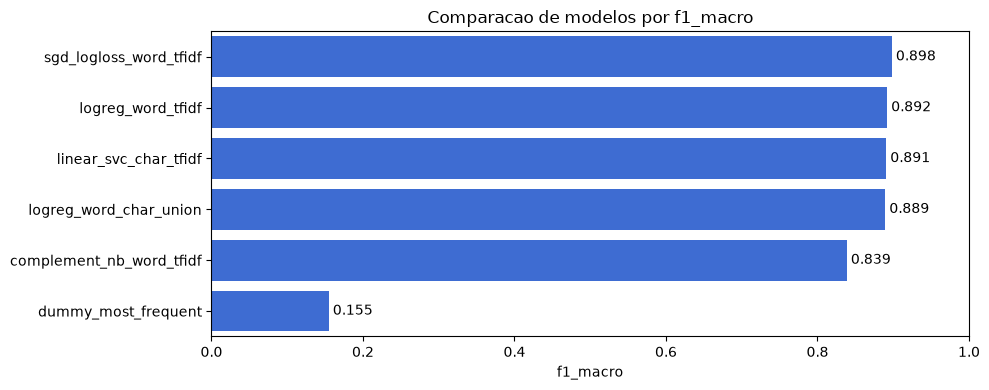

In [11]:
experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)

classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
results_df, fitted_models = evaluate_model_zoo(
    train_clean,
    models=classical_models,
    config=experiment_config,
)

ranked = rank_results(results_df, metric="f1_macro")
display(ranked)
plot_metric_comparison(results_df, metric="f1_macro")

results_path = save_results_table(results_df, OUTPUT_DIR / "model_results_holdout.csv")
print("Resultados holdout salvos em:", results_path)

---
## 6. Validação cruzada dos melhores modelos clássicos

O holdout é rápido e útil para comparar muitas alternativas, mas uma única divisão pode favorecer ou prejudicar modelos por acaso. Por isso, após o ranking inicial, aplicamos validação cruzada apenas nos três melhores modelos clássicos. Essa etapa é mais custosa, porém fornece uma estimativa mais estável do desempenho médio.


In [12]:
top_model_names = ranked.head(3)["model"].tolist()
cv_results = cross_validate_best_models(
    train_clean,
    model_names=top_model_names,
    models=build_sparse_model_zoo(random_state=experiment_config.random_state),
    config=experiment_config,
)

cv_results_path = OUTPUT_DIR / "model_results_cv_top3.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results)
print("Resultados de validação cruzada salvos em:", cv_results_path)

/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWa

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,sgd_logloss_word_tfidf,0.920047,0.004517,0.902755,0.007641,0.919957,0.004516
1,linear_svc_char_tfidf,0.913580,0.005823,0.897519,0.007443,0.914132,0.005745
2,logreg_word_tfidf,0.905448,0.004891,0.891621,0.006605,0.907320,0.004822


Resultados de validação cruzada salvos em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/model_results_cv_top3.csv


---
## 7. Análise do melhor modelo clássico

Nesta etapa, olhamos para além do número agregado. A matriz de confusão mostra quais classes estão sendo trocadas entre si, e o relatório por classe mostra se o problema está em precisão, revocação ou ambos.

Essa leitura é fundamental para orientar melhorias futuras. Se a classe `2` tem baixo recall, por exemplo, pode ser necessário enriquecer features de despachos ou revisar exemplos curtos. Se `1` e `3` se confundem, talvez seja preciso modelar melhor trechos com referências a ARE e RE.


Melhor modelo clássico no holdout: sgd_logloss_word_tfidf


,precision,recall,f1-score,support
0,0.872340,0.924812,0.897810,133.000000
1,0.826458,0.822946,0.824698,706.000000
2,0.947368,0.818182,0.878049,88.000000
3,0.945334,0.940194,0.942757,2575.000000
4,0.930233,0.963855,0.946746,581.000000
accuracy,0.920157,0.920157,0.920157,0.920157
macro avg,0.904347,0.893998,0.898012,4083.000000
weighted avg,0.920296,0.920157,0.920052,4083.000000


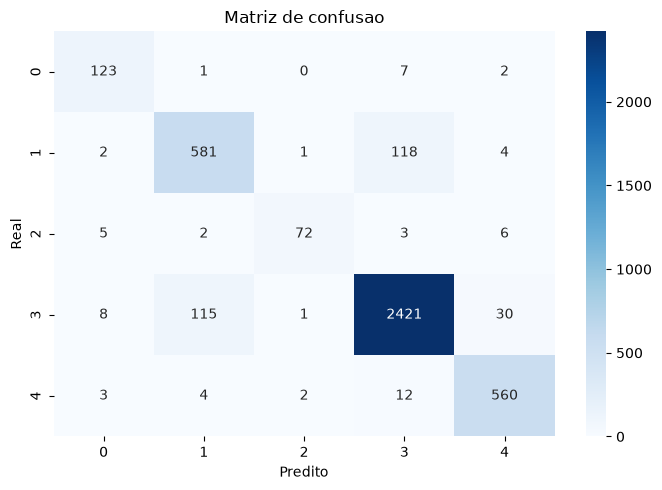

In [14]:
best_name, best_holdout_model = select_best_model(results_df, fitted_models, metric="f1_macro")
print("Melhor modelo clássico no holdout:", best_name)

best_info = fitted_models[best_name]
plot_confusion_matrix(best_info["y_valid"], best_info["y_pred"], labels=[0, 1, 2, 3, 4])
display(classification_report_frame(best_info["classification_report"]))

---

## 8. Auditoria de rótulos, pseudo-rotulagem e treino final clássico

A primeira rodada de modelos clássicos serve para escolher uma boa família de baseline. Antes do treino final, usamos esse conhecimento para melhorar a base de treinamento de forma conservadora.

A estratégia tem duas partes independentes:

1. **Auditoria de rótulos existentes:** um modelo probabilístico faz previsões fora da dobra nas amostras rotuladas. Quando a previsão discorda do rótulo original com confiança alta, a linha é registrada em `outputs/potential_label_issues.csv`. Apenas casos com confiança ainda maior são corrigidos automaticamente, mantendo `OriginalCategory` para rastreabilidade.

2. **Pseudo-rotulagem das amostras `Category = -1`:** treinamos o modelo de auditoria nas amostras válidas e aplicamos nas linhas sem rótulo. Só entram no treino final os exemplos com confiança acima do limiar definido. O arquivo `outputs/pseudo_labeled_samples.csv` guarda os pseudo-rótulos e suas confianças.

Com isso, o treino final deixa de ignorar milhares de textos sem rótulo, mas evita contaminar o pipeline com previsões fracas. Se no futuro essa etapa precisar ser refeita, basta ajustar os limiares ou substituir o modelo de auditoria sem mexer no restante do fluxo.


In [15]:
audit_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
label_audit_model_name = "logreg_word_tfidf" if "logreg_word_tfidf" in audit_models else best_name

print("Modelo usado para auditoria e pseudo-rotulagem:", label_audit_model_name)

label_issues = detect_label_issues_with_cv(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
    min_confidence=0.85,
)
label_issues_path = OUTPUT_DIR / "potential_label_issues.csv"
label_issues.to_csv(label_issues_path, index=False)

label_audit_model = fit_model_on_full_train(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
)

unlabeled_clean = add_clean_text_column(train_unlabeled, config=preprocess_config)
pseudo_labeled, pseudo_report = pseudo_label_unlabeled_samples(
    unlabeled_clean,
    label_audit_model,
    config=experiment_config,
    min_confidence=0.92,
)
pseudo_labeled_path = OUTPUT_DIR / "pseudo_labeled_samples.csv"
pseudo_labeled.to_csv(pseudo_labeled_path, index=False)

train_modeling = build_training_set_with_pseudo_labels(
    train_clean,
    pseudo_labeled,
    label_issues=label_issues,
    config=experiment_config,
    correction_min_confidence=0.97,
)

summary_audit = pd.DataFrame(
    [
        {
            "rotuladas_originais": len(train_clean),
            "sem_rotulo_disponiveis": len(train_unlabeled),
            "pseudo_rotuladas_usadas": pseudo_report["selected"],
            "possiveis_rotulos_ruidosos": len(label_issues),
            "correcoes_automaticas": int((train_modeling["LabelAuditAction"] == "auto_corrected").sum()),
            "total_treino_final": len(train_modeling),
        }
    ]
)
display(summary_audit)
print("Auditoria salva em:", label_issues_path)
print("Pseudo-rótulos salvos em:", pseudo_labeled_path)

if not label_issues.empty:
    display(label_issues.head(10))
if not pseudo_labeled.empty:
    display(pseudo_labeled[["Id", "Category", "PseudoConfidence", "PseudoConfidenceMargin"]].head(10))

final_classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
final_classical_model = fit_model_on_full_train(
    train_modeling,
    final_classical_models[best_name],
    config=experiment_config,
)

classical_model_path = save_model(final_classical_model, MODEL_DIR / f"{best_name}.joblib")
submission_classical = generate_submission(
    final_classical_model,
    test_clean,
    output_path=OUTPUT_DIR / "submission.csv",
    text_col="Body_clean",
    id_col="Id",
)

print("Modelo clássico salvo em:", classical_model_path)
print("Submissão clássica salva em:", OUTPUT_DIR / "submission.csv")
display(submission_classical.head())


Modelo usado para auditoria e pseudo-rotulagem: logreg_word_tfidf


/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWa

,rotuladas_originais,sem_rotulo_disponiveis,pseudo_rotuladas_usadas,possiveis_rotulos_ruidosos,correcoes_automaticas,total_treino_final
0,20412,2268,1257,82,8,21669


Auditoria salva em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/potential_label_issues.csv
Pseudo-rótulos salvos em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/pseudo_labeled_samples.csv


,Id,Category,SuggestedCategory,SuggestedConfidence,SuggestedConfidenceMargin,Body_clean
0,10782,3,0,0.995509,0.993394,por ltimo visando evitar descabidos protelata rios embargos declaraa artigo ressalte que na existe menor necessidade manifestaa artigo expressa sobre todos ...
1,11127,3,0,0.993907,0.990927,por fim visando evitar descabidos protelata rios embargos declaraa artigo ressalte que na existe menor necessidade manifestaa artigo expressa sobre todos ar...
2,10824,1,2,0.986141,0.978821,alega recorrente sa ntese que decisum ora impugnado fere frontalmente artigo_ constituia artigo federal mata ria versada pea artigo recursal exame foi objet...
3,10371,3,0,0.983239,0.972396,reajustes dos benefa cios previdencia rios tais como inpc irsm vindo depois urv ipc igp outros fato que na qualquer previsa equiparaa artigo percentual majo...
4,10938,3,0,0.982992,0.975089,aos tetos fixados pelas emendas constitucionais foi aplicado reajuste integral conforme determinaa artigo constante das pra prias emendas constitucionais de...
5,17740,4,2,0.980988,0.971395,assim julgo improcedentes embargos execua artigo determino que seja feita correa artigo moneta ria pelo ndice ipca contar data expedia artigo rpv ata seu ef...
6,10781,3,0,0.975678,0.964696,segundo alega parte recorrente poder executivo promoveu sem autorizaa artigo legislativa aumento acima limite cobertura previdencia ria que toca teto dos be...
7,17734,4,2,0.971642,0.963537,fixada pelo quer seja do artigo_ cpc devem levar consideraa artigo grau zelo profissional local prestaa artigo servia artigo natureza importa ncia causa tra...
8,11034,3,0,0.969965,0.958039,vez que teto for estes benefa cios devem ser corrigidos para preservaa artigo seu valor acordo com inflaa artigo que feito nos dias atuais anualmente assim ...
9,24212,3,0,0.965476,0.944600,com publicaa artigo emenda constitucional dezembro foi fixado limite ma ximo para valor dos benefa cios regime geral previda ncia prevendo ainda que sua atu...


,Id,Category,PseudoConfidence,PseudoConfidenceMargin
0,25112,3,0.956524,0.922894
1,23109,3,0.956379,0.921445
2,21334,4,0.989839,0.986326
3,20980,3,0.982949,0.974279
4,7787,3,0.971882,0.956439
5,13602,3,0.931042,0.890826
6,23729,1,0.970352,0.948722
7,13789,3,0.958372,0.930209
8,2605,1,0.995655,0.993814
9,3637,3,0.954824,0.912612


Modelo clássico salvo em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/models/sgd_logloss_word_tfidf.joblib
Submissão clássica salva em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/submission.csv


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---

## 9. Representação densa com SentenceTransformers

TF-IDF representa documentos por frequência de termos. Isso é muito forte para textos jurídicos porque termos como `agravo`, `recurso extraordinario`, `acordao`, `sentenca` e fórmulas processuais são altamente discriminativos. Por isso, é normal que um baseline TF-IDF bem ajustado supere embeddings congelados em algumas divisões.

A versão anterior desta seção codificava cada documento inteiro de uma vez. Esse desenho pode derrubar o resultado porque modelos SentenceTransformer têm janela limitada e acabam representando principalmente o início do texto. Para corrigir isso, usamos `build_chunked_sentence_embedding_matrix`: cada documento é dividido em chunks sobrepostos, os chunks são codificados no dispositivo disponível (`cuda`, `mps` ou `cpu`) e depois agregados em um único vetor por documento.

Essa etapa continua sendo independente: ela recebe `Body_clean`, devolve uma matriz densa e treina classificadores em cima dela. Se encontrarmos um embedding jurídico melhor no futuro, só trocamos `embedding_model_name`.


In [16]:
embedding_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embedding_batch_size = max(1, runtime_profile["transformer_batch_size"] * 2)

embeddings_train = build_chunked_sentence_embedding_matrix(
    train_modeling["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)
embeddings_test = build_chunked_sentence_embedding_matrix(
    test_clean["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)

embeddings_labeled_only = embeddings_train[: len(train_clean)]
embedding_results, embedding_models = evaluate_embedding_classifier(
    train_clean,
    embeddings_labeled_only,
    config=experiment_config,
)
display(embedding_results)


/home/loren_gc/BCC/7º SEMESTRE/pln/COURT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 1859/1859 [04:05<00:00,  7.57it/s]


,model,accuracy,f1_macro,f1_weighted
1,embedding_linear_svc,0.774675,0.685443,0.776649
0,embedding_logreg,0.689444,0.602104,0.706430


In [17]:
best_embedding_name = embedding_results.iloc[0]["model"]
final_embedding_model = fit_embedding_classifier_on_full_train(
    train_modeling,
    embeddings_train,
    model_name=best_embedding_name,
    config=experiment_config,
)

embedding_model_path = save_model(final_embedding_model, MODEL_DIR / f"{best_embedding_name}.joblib")
submission_embeddings = generate_embedding_submission(
    final_embedding_model,
    embeddings_test,
    test_clean["Id"],
    output_path=OUTPUT_DIR / "submission_embeddings.csv",
)

print("Modelo de embeddings salvo em:", embedding_model_path)
print("Submissão de embeddings salva em:", OUTPUT_DIR / "submission_embeddings.csv")
display(submission_embeddings.head())


Modelo de embeddings salvo em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/models/embedding_linear_svc.joblib
Submissão de embeddings salva em: /home/loren_gc/BCC/7º SEMESTRE/pln/COURT/template-implementacao/outputs/submission_embeddings.csv


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---

## 10. Fine-tuning de Transformer

A etapa final usa um modelo de linguagem pré-treinado. Para português brasileiro, o candidato padrão é o BERTimbau (`neuralmind/bert-base-portuguese-cased`), que tende a ser uma escolha sólida para tarefas em português. O notebook também lista alternativas úteis, como Albertina, Longformer e ModernBERT.

Diferente de uma abordagem baseada apenas em embeddings congelados, o fine-tuning ajusta os pesos do modelo para a tarefa específica. Isso costuma melhorar desempenho quando há dados rotulados suficientes, mas aumenta o custo computacional.

A função `fine_tune_transformer_classifier` ajusta automaticamente:

- dispositivo: `cuda`, `mps` ou `cpu`;
- batch size;
- `fp16`/`bf16` quando CUDA suporta;
- pesos de classe na função de perda, úteis por causa do desbalanceamento;
- compatibilidade com versões novas e antigas do `transformers`, incluindo a mudança de `tokenizer` para `processing_class`;
- salvamento do melhor checkpoint por `f1_macro`.

Em CPU, essa etapa pode demorar bastante, mas o código continua sendo executável. Em Mac com Apple Silicon, o modelo é movido para `mps`. Em servidor NVIDIA, vai para `cuda`.


In [24]:
display(transformer_candidate_models())
print("Ambiente detectado para o fine-tuning:")
display(pd.DataFrame([runtime_profile["environment"]]))

,model_id,family,why,max_length
0,neuralmind/bert-base-portuguese-cased,BERTimbau,Strong Brazilian Portuguese encoder baseline.,512
1,neuralmind/bert-large-portuguese-cased,BERTimbau Large,Larger Portuguese encoder when GPU memory allows.,512
2,PORTULAN/albertina-ptbr-base,Albertina PT-BR,Open Portuguese DeBERTa-style encoder trained for PT-BR.,512
3,answerdotai/ModernBERT-base,ModernBERT,Efficient long-context encoder; useful for long legal pages.,8192
4,allenai/longformer-base-4096,Longformer,Long-document attention baseline for documents above 512 tokens.,4096


Ambiente detectado para o fine-tuning:


,torch_installed,torch_version,preferred_device,cuda_available,cuda_device_count,mps_available,devices,fp16_recommended,bf16_supported
0,True,2.12.1+cpu,cpu,False,0,False,[],False,False


In [24]:
trainer = fine_tune_transformer_classifier(
    train_modeling,
    model_name=runtime_profile["recommended_transformer"],
    config=experiment_config,
    num_train_epochs=runtime_profile["transformer_epochs"],
    learning_rate=runtime_profile["transformer_learning_rate"],
    per_device_train_batch_size=runtime_profile["transformer_batch_size"],
    max_length=runtime_profile["transformer_max_length"],
    output_dir=str(OUTPUT_DIR / "bertimbau"),
    use_class_weights=True,
    use_lora=runtime_profile["use_lora"],
    quantization_4bit=runtime_profile["quantization_4bit"],
    device=runtime_profile["device"],
)

submission_transformer = generate_transformer_submission(
    trainer,
    test_clean,
    output_path=OUTPUT_DIR / "submission_transformer.csv",
    text_col="Body_clean",
    id_col="Id",
    max_length=runtime_profile["transformer_max_length"],
)

print("Submissão Transformer salva em:", OUTPUT_DIR / "submission_transformer.csv")
display(submission_transformer.head())


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 29372.08it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'no_cuda'

---
## 11. Consolidação dos resultados

Ao final do pipeline, teremos pelo menos três submissões:

- `outputs/submission.csv`: melhor modelo clássico;
- `outputs/submission_embeddings.csv`: classificador sobre embeddings densos;
- `outputs/submission_transformer.csv`: modelo Transformer fine-tuned.

A escolha final para envio ao Kaggle deve combinar desempenho local, estabilidade em validação cruzada e resultado público no leaderboard. Em geral, a submissão Transformer tende a ser mais forte, mas os modelos clássicos são úteis como controle: se o Transformer não superar claramente o baseline TF-IDF, isso pode indicar problema de truncamento, hiperparâmetros ou ruído no pré-processamento.


In [ ]:
print("Arquivos gerados em outputs/:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

print("
Modelos salvos em models/:")
for path in sorted(MODEL_DIR.glob("*.joblib")):
    print("-", path)


---

## 12. Próximos ciclos de melhoria

Com o pipeline completo funcionando, os próximos ciclos devem ser incrementais e independentes:

1. **Pré-processamento:** comparar manter/remover stopwords, testar lematização e avaliar impacto em `f1_macro`;
2. **Auditoria de rótulos:** revisar manualmente `outputs/potential_label_issues.csv` e ajustar os limiares de correção automática;
3. **Pseudo-rotulagem:** testar limiares diferentes e comparar o treino com/sem exemplos pseudo-rotulados;
4. **Textos longos:** comparar pooling por chunks, agregação de probabilidades e modelos de contexto longo;
5. **Modelos clássicos:** ajustar `min_df`, `max_features`, n-gramas e regularização;
6. **Embeddings:** testar modelos jurídicos ou multilíngues mais recentes;
7. **Transformer:** comparar BERTimbau, Albertina e modelos de contexto longo;
8. **PEFT/LoRA:** em ambiente NVIDIA/Linux, instalar `requirements-nvidia.txt` e testar QLoRA para reduzir memória;
9. **Análise de erros:** inspecionar amostras confundidas, principalmente entre ARE e RE.

A estrutura modular permite trocar qualquer uma dessas partes sem reescrever o notebook inteiro.
